# Book Review Quality Classification using Snorkel
**Goal:** To label Amazon book reviews as HIGH_QUALITY (substantive book review) or LOW_QUALITY (transaction review, no-content, trolling) using weak supervision. Then train a classifier that generalizes.

## 1. Data Loading & Cleaning

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import html
import re

warnings.filterwarnings('ignore')
SAMPLE_FRAC = 0.005  # ~2.86GB file, so sampling it to keep it simple, understandable, and manageable
SEED = 42

In [2]:
# Load ratings in chunks and sample
chunks = pd.read_csv(f"Books_rating.csv", chunksize=100000)
sampled = [chunk.sample(frac=SAMPLE_FRAC, random_state=SEED) for chunk in chunks]
df_raw = pd.concat(sampled).reset_index(drop=True)
print(f"Sampled {len(df_raw)} reviews")
df_raw.head(3)

Sampled 15000 reviews


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,0786280670,"Julie and Julia: 365 Days, 524 Recipes, 1 Tiny...",NaN,A253PNGDYGE7PK,J. A.,4/4,3.0,1298851200,good and bad,I was very surprised by this book. I like the ...
1,0446519464,The Tao of Muhammad Ali,NaN,A3S1A316E56U39,mattparry@yahoo.com,19/20,5.0,980035200,Davis Miller: The Greatest Muhammad Ali Writer...,The book is a biography of the life of author ...
2,B000I3JBUO,One Hundred Years of Solitude,NaN,A31748SXZ7N2UN,John,3/4,5.0,1031356800,remember your grandmother,with many reviews that were already written fo...


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  15000 non-null  str    
 1   Title               14999 non-null  str    
 2   Price               2412 non-null   float64
 3   User_id             12215 non-null  str    
 4   profileName         12215 non-null  str    
 5   review/helpfulness  15000 non-null  str    
 6   review/score        15000 non-null  float64
 7   review/time         15000 non-null  int64  
 8   review/summary      14996 non-null  str    
 9   review/text         15000 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 1.1 MB


In [4]:
df_raw.isnull().sum()

Id                        0
Title                     1
Price                 12588
User_id                2785
profileName            2785
review/helpfulness        0
review/score              0
review/time               0
review/summary            4
review/text               0
dtype: int64

### Clean the ratings data

In [5]:
df = df_raw.copy()

df = df.dropna(subset=["review/text"])
df["profileName"] = df["profileName"].fillna("Anonymous")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["review/score"] = df["review/score"].astype(int)

print(f"After dropping null text: {len(df)} reviews")

After dropping null text: 15000 reviews


In [6]:
pd.set_option("display.max_colwidth", None)
df["review/text"].sample(10)

6632                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [7]:
# Decodig HTML entities — &quot; &amp; &lt; etc.
df["review/text"] = df["review/text"].apply(lambda x: html.unescape(str(x)))
df["review/summary"] = df["review/summary"].apply(lambda x: html.unescape(str(x)))

# Fixing missing spaces: "word.Another" --> "word. Another"
df["review/text"] = df["review/text"].apply(
    lambda x: re.sub(r'([.!?])([A-Z])', r'\1 \2', str(x))
)

df["review/text"].iloc[0][:300]

'I was very surprised by this book. I like the premise - blogging about cooking all the recipes in a classic, challenging cookbook and finding joy and a new career along the way. But the main character in this book is hateful. She comes across as that dorky co-worker in the cubicle next to you that y'

In [8]:
# separate helpfulness fraction "7/11" -> two int columns
def separate_helpful(h):
    try:
        parts = str(h).split("/")
        return int(parts[0]), int(parts[1])
    except:
        return 0, 0

df["helpful"], df["total_votes"] = zip(*df["review/helpfulness"].apply(separate_helpful))
df["help_ratio"] = df.apply(
    lambda r: r["helpful"] / r["total_votes"] if r["total_votes"] > 0 else np.nan, axis=1
)

df[["review/helpfulness", "helpful", "total_votes", "help_ratio"]].head()

,review/helpfulness,helpful,total_votes,help_ratio
0,4/4,4,4,1.00
1,19/20,19,20,0.95
2,3/4,3,4,0.75
3,0/0,0,0,NaN
4,1/1,1,1,1.00


In [9]:
# Convert to unix timestamp
df["review_date"] = pd.to_datetime(df["review/time"], unit="s", errors="coerce")

# Precomputing text lengths as that would make an ease for later use
df["word_count"] = df["review/text"].apply(lambda x: len(str(x).split()))
df["summary_len"] = df["review/summary"].apply(lambda x: len(str(x).split()))

before = len(df)
df = df.drop_duplicates(subset=["Title", "review/text"], keep="first")
print(f"Removed {before - len(df)} duplicate reviews")

Removed 20 duplicate reviews


In [10]:
# Load and join book metadata
df_books = pd.read_csv(f"books_data.csv")
df_books.sample(3)

,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
78284,Conservative Management of Sports Injuries,"This text embraces the philosophy of 'active' conservative care and a multidisciplinary team approach to treatment. It addresses site specific sports injuries, as well as diagnostic imaging, strength and conditioning, nutrition and steriod use.","['Thomas E. Hyde', 'Marianne S. Gengenbach']",http://books.google.com/books/content?id=uzPwfNYyjjUC&printsec=frontcover&img=1&zoom=1&edge=curl&source=gbs_api,http://books.google.com/books?id=uzPwfNYyjjUC&printsec=frontcover&dq=Conservative+Management+of+Sports+Injuries&hl=&cd=1&source=gbs_api,Jones & Bartlett Learning,2007,http://books.google.com/books?id=uzPwfNYyjjUC&dq=Conservative+Management+of+Sports+Injuries&hl=&source=gbs_api,['Medical'],3.0
161685,The Christy Quest,NaN,['Helen F. Copley'],http://books.google.com/books/content?id=fnQGAAAACAAJ&printsec=frontcover&img=1&zoom=1&source=gbs_api,http://books.google.com/books?id=fnQGAAAACAAJ&dq=The+Christy+Quest&hl=&cd=1&source=gbs_api,NaN,1999-01-01,http://books.google.com/books?id=fnQGAAAACAAJ&dq=The+Christy+Quest&hl=&source=gbs_api,['Illustrators'],NaN
34386,Epidemiology for the Health Sciences: A Primer on Epidemiologic Concepts and Their Uses,NaN,['Donald F. Austin'],NaN,http://books.google.com/books?id=xBPQoQEACAAJ&dq=Epidemiology+for+the+Health+Sciences:+A+Primer+on+Epidemiologic+Concepts+and+Their+Uses&hl=&cd=1&source=gbs_api,Charles C. Thomas Publisher,2014-05-14,http://books.google.com/books?id=xBPQoQEACAAJ&dq=Epidemiology+for+the+Health+Sciences:+A+Primer+on+Epidemiologic+Concepts+and+Their+Uses&hl=&source=gbs_api,['HEALTH & FITNESS'],NaN


In [11]:
from ast import literal_eval

def safe_list(x):
    try: return literal_eval(str(x))
    except: return []

df_books["category"] = df_books["categories"].apply(
    lambda x: safe_list(x)[0] if safe_list(x) else "Unknown"
)

In [12]:
# Merge — Using left join to keep all reviews into merged df
df = df.merge(
    df_books[["Title", "category", "description"]].drop_duplicates(subset=["Title"]),
    on="Title", how="left"
)
df["category"] = df["category"].fillna("Unknown")

print(f"Final cleaned dataset: {len(df)} reviews")
df.head()

Final cleaned dataset: 14980 reviews


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text,helpful,total_votes,help_ratio,review_date,word_count,summary_len,category,description
0,0786280670,"Julie and Julia: 365 Days, 524 Recipes, 1 Tiny Apartment Kitchen: How One Girl Risked Her Marriage, Her Job, and Her ... Living",NaN,A253PNGDYGE7PK,J. A.,4/4,3,1298851200,good and bad,"I was very surprised by this book. I like the premise - blogging about cooking all the recipes in a classic, challenging cookbook and finding joy and a new career along the way. But the main character in this book is hateful. She comes across as that dorky co-worker in the cubicle next to you that you never wanted to know. Dorky is not hateful, but complete lack of character is. She envies her friends when they gravitate towards loser-behavior. (Her friend purposefully puts herself in the position of being used by a cheesy married man and Julie envies her.) She is ungrateful for what she has. She seems to think infidelity is cool. She's terrible to her husband and seems to have no control over her behavior and outbursts. She tells us how she puts the butter in her husband's bag without him knowing, as if that is cute and impish. It's closer to evil. She's afraid of turning into her mother, but aside from her mother's childish and disrespectful response to blog reader Clarence, the character in this book is much worse than her mother. She finds out when she's a child that her dad fell out of love with her mother and you wonder if Julie is testing her spouse's limits to see if he'll do the same. There are some mysteries in the book: Why would a guy as good as Eric stay with Julie in a city where there is a good-man drought? Why would anyone eat at her maggot-infested apartment? Why don't they hire a cleaning service, at least once? It's clear that she is very nave and she doesn't know what it's like to date in the city or be in the midst of any kind of real hardship/war/tragedy. Her analogies are out of touch to the point of being painful, and she makes Democrats and liberals look really bad. The writing in the beginning is very bad, but picks up a little later. But I didn't give the book a one-star rating because, believe it or not, there are some pluses. For one thing, look at all the reviews. If a book is truly bad, I don't think this many people will feel moved to write. She gives us a character that we love to hate. She's everything we don't want to be. She describes herself as dirty, flabby, petty, hints at being bad in bed, not too bright, definitely not worldly, etc. Doesn't that honesty sort of make her a good writer? If she was truly narcissistic, wouldn't she cover up those aspects of her personality? (Unless she's just that clueless?!) In fact, she is honest enough to let the reader see that Eric and her brother are much better humans than she. Also, her descriptions of the cooking process are actually good and it's very cool that she finished each recipe, no matter what it took. The movie was delightful. I remember thinking the main character in the movie was dorky, but not hateful. In conclusion, I would read this book, but I'd get it at the library.",4,4,1.00,2011-02-28,518,3,"Cookery, French","Pushing thirty, living in a rundown apartment in Queens and working at a dead-end secretarial job, Julie Powell is, in a word, stuck. In her desperate search for an escape, she comes up instead with The Project - a deranged assignment, to take her mother's dog-eared copy of Julia Child's 1961 classic Mastering the Art of French Cooking and cook all 524 recipes. In the span of one year."
1,0446519464,The Tao of Muhammad Ali,NaN,A3S1A316E56U39,mattparry@yahoo.com,19/20,5,980035200,Davis Miller: The Greatest Muhammad Ali Writer Of All Times,"The book is a biography of the life of author Davis Miller and not of Muhammad Ali as one might first think. It follows his life from high school to the near present day and details his growing fascinati

In [13]:
df[["review/score", "word_count", "helpful", "total_votes", "help_ratio"]].describe()

,review/score,word_count,helpful,total_votes,help_ratio
count,14980.000000,14980.000000,14980.000000,14980.000000,10521.000000
mean,4.227437,143.728438,4.457877,6.558278,0.700827
std,1.194546,170.412389,11.993557,15.807478,0.342365
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,47.000000,0.000000,0.000000,0.500000
50%,5.000000,92.000000,1.000000,2.000000,0.833333
75%,5.000000,177.000000,4.000000,6.000000,1.000000
max,5.000000,5266.000000,286.000000,427.000000,1.000000


In [14]:
df["category"].value_counts().head(10)

category
Fiction                      4087
Unknown                      2833
Juvenile Fiction             1013
Biography & Autobiography     535
Religion                      492
History                       431
Business & Economics          301
Computers                     217
Juvenile Nonfiction           171
Young Adult Fiction           150
Name: count, dtype: int64

### Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.15, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)}, Test: {len(df_test)}")

Train: 12733, Test: 2247


In [16]:
ABSTAIN = -1
LOW_QUALITY = 0
HIGH_QUALITY = 1

## 2. Writing Labeling Functions

In [17]:
# !pip install snorkel

In [18]:
from snorkel.labeling import labeling_function, LabelingFunction

### a) Helpfulness-based LFs

In [19]:
@labeling_function()
def lf_very_helpful(x):
    if x.total_votes >= 5 and x.help_ratio > 0.8:
        return HIGH_QUALITY
    return ABSTAIN

@labeling_function()
def lf_mostly_unhelpful(x):
    if x.total_votes >= 5 and x.help_ratio < 0.3:
        return LOW_QUALITY
    return ABSTAIN

### b) Transaction/non-review detectors

In [20]:
@labeling_function()
def lf_transaction(x):
    """Reviews about shipping/condition, not the book."""
    phrases = [
        "shipped promptly", "arrived on time", "great transaction",
        "good condition", "as described", "well packaged",
        "fast shipping", "needed it for class", "required for class",
        "textbook for", "bought this for school"
    ]
    txt = str(x["review/text"]).lower()
    if any(p in txt for p in phrases) and x.word_count < 50:
        return LOW_QUALITY
    return ABSTAIN

@labeling_function()
def lf_gift_review(x):
    """Reviews that are about giving the book as a gift. Since the person gifting it is most probably not going to read"""
    txt = str(x["review/text"]).lower()
    if re.search(r"(bought|ordered|got)\s+(this|it)\s+(as|for)\s+a?\s*gift", txt):
        return LOW_QUALITY
    return ABSTAIN

### c) Keyword LFs

In [21]:
def kw_lookup(x, keywords, label):
    if any(w in str(x["review/text"]).lower() for w in keywords):
        return label
    return ABSTAIN

def make_kw_lf(keywords, label, name=None):
    return LabelingFunction(
        name=name or f"kw_{keywords[0].replace(' ', '_')}",
        f=kw_lookup,
        resources=dict(keywords=keywords, label=label),
    )

# Substantive review signals
kw_literary = make_kw_lf(
    ["character development", "plot twist", "narrative", "prose style",
     "writing style", "well-written", "poorly written", "page-turner"],
    HIGH_QUALITY, "kw_literary"
)

kw_analysis = make_kw_lf(
    ["thesis", "the author argues", "in chapter", "bibliography",
     "footnotes", "well researched", "primary source"],
    HIGH_QUALITY, "kw_analysis"
)

kw_comparison = make_kw_lf(
    ["compared to", "reminds me of", "similar to", "better than",
     "unlike", "on par with"],
    HIGH_QUALITY, "kw_comparison"
)

# Low quality signals
kw_meta = make_kw_lf(
    ["fake reviews", "other reviewers", "5 star reviews must",
     "don't trust the reviews", "reviewers are"],
    LOW_QUALITY, "kw_meta_review"
)

### d) Heuristic LFs

In [22]:
@labeling_function()
def lf_very_short(x):
    if x.word_count < 10:
        return LOW_QUALITY
    return ABSTAIN

@labeling_function()
def lf_substantial_length(x):
    # 150+ word reviews with moderate scores tend to be thoughtful
    if x.word_count >= 150 and 2 <= x["review/score"] <= 4:
        return HIGH_QUALITY
    return ABSTAIN

@labeling_function()
def lf_summary_is_review(x):
    """When summary and text are nearly identical, review has no depth."""
    s = str(x["review/summary"]).strip().lower()
    t = str(x["review/text"]).strip().lower()
    if s == t or (len(t) > 0 and len(s) > 0 and t.startswith(s) and x.word_count < 20):
        return LOW_QUALITY
    return ABSTAIN

### e) Regex pattern LFs

In [23]:
@labeling_function()
def lf_regex_recommend(x):
    """Strong recommendation language with reasoning."""
    txt = str(x["review/text"])
    if re.search(r"(highly recommend|must[- ]read|essential reading)", txt, re.I) and x.word_count > 40:
        return HIGH_QUALITY
    return ABSTAIN

@labeling_function()
def lf_regex_stars(x):
    """People writing 'I give this book X stars' in short text = low depth."""
    txt = str(x["review/text"])
    if re.search(r"\d\s*stars?\.?\s*$", txt, re.I) and x.word_count < 25:
        return LOW_QUALITY
    return ABSTAIN

@labeling_function()
def lf_regex_spoiler_warn(x):
    """Spoiler warnings = reviewer actually read and is discussing content."""
    if re.search(r"(spoiler|warning.*plot|don'?t read.*if)", str(x["review/text"]), re.I):
        return HIGH_QUALITY
    return ABSTAIN

### f) TextBlob sentiment LFs

In [24]:
# !pip install textblob

In [25]:
from textblob import TextBlob
from snorkel.preprocess import preprocessor

In [26]:
@preprocessor(memoize=True)
def tb_sentiment(x):
    blob = TextBlob(str(x["review/text"]))
    x.polarity = blob.sentiment.polarity
    x.subjectivity = blob.sentiment.subjectivity
    return x

@labeling_function(pre=[tb_sentiment])
def lf_balanced_opinion(x):
    """Mix of subjective and objective = substantive review."""
    if 0.25 < x.subjectivity < 0.65 and x.word_count > 60:
        return HIGH_QUALITY
    return ABSTAIN

@labeling_function(pre=[tb_sentiment])
def lf_extreme_short(x):
    """Very polarized and very short = no valeu."""
    if abs(x.polarity) > 0.8 and x.word_count < 15:
        return LOW_QUALITY
    return ABSTAIN

@labeling_function(pre=[tb_sentiment])
def lf_score_text_mismatch(x):
    """5 stars but negative text, or 1 star but positive text."""
    score = x["review/score"]
    if score == 5 and x.polarity < -0.1:
        return LOW_QUALITY
    if score == 1 and x.polarity > 0.5:
        return LOW_QUALITY
    return ABSTAIN

### g) Category-enriched LF (from joined metadata)

In [27]:
@labeling_function()
def lf_academic_deep(x):
    """Long reviews on non-fiction/academic books are usually substantive."""
    acad = ["Biography", "History", "Science", "Philosophy", "Political Science",
            "Religion", "Education", "Law"]
    if any(c in str(x.category) for c in acad) and x.word_count > 120:
        return HIGH_QUALITY
    return ABSTAIN

## 3. Applying LFs and Analyzing

In [28]:
from snorkel.labeling import PandasLFApplier, LFAnalysis

In [29]:
lfs = [
    lf_very_helpful,
    lf_mostly_unhelpful,
    lf_transaction,
    lf_gift_review,
    kw_literary,
    kw_analysis,
    kw_comparison,
    kw_meta,
    lf_very_short,
    lf_substantial_length,
    lf_summary_is_review,
    lf_regex_recommend,
    lf_regex_stars,
    lf_regex_spoiler_warn,
    lf_balanced_opinion,
    lf_extreme_short,
    lf_score_text_mismatch,
    lf_academic_deep,
]

print(f"Total LFs: {len(lfs)}")

Total LFs: 18


In [30]:
applier = PandasLFApplier(lfs=lfs)
L_train = applier.apply(df=df_train)
L_test = applier.apply(df=df_test)

100%|█████████████████████████████████████| 2247/2247 [00:00<00:00, 2399.16it/s]


In [31]:
LFAnalysis(L=L_train, lfs=lfs).lf_summary()

,j,Polarity,Coverage,Overlaps,Conflicts
lf_very_helpful,0,[1],0.150397,0.130448,0.003141
lf_mostly_unhelpful,1,[0],0.046101,0.025681,0.023404
lf_transaction,2,[0],0.004869,0.000942,0.000000
lf_gift_review,3,[0],0.000550,0.000157,0.000157
kw_literary,4,[1],0.052855,0.047279,0.002906
kw_analysis,5,[1],0.015786,0.014529,0.000785
kw_comparison,6,[1],0.050263,0.044844,0.003613
kw_meta_review,7,[0],0.006911,0.006518,0.006518
lf_very_short,8,[0],0.002513,0.001021,0.000000
lf_substantial_length,9,[1],0.126836,0.125187,0.006126


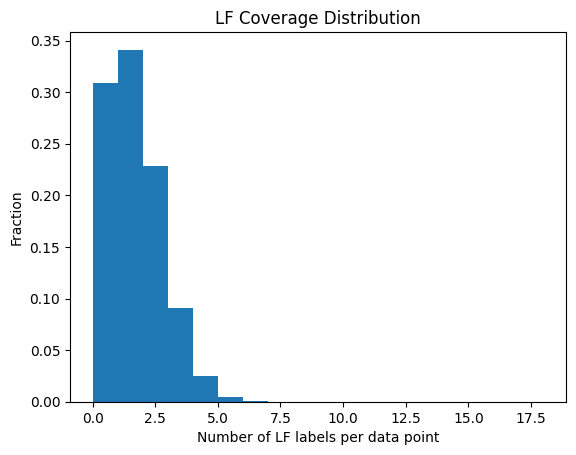

Unlabeled (0 LFs): 3936 / 12733


In [32]:
# Coverage distribution — how many LFs label each data point
import matplotlib.pyplot as plt
%matplotlib inline

coverage_per_point = (L_train != ABSTAIN).sum(axis=1)
plt.hist(coverage_per_point, bins=range(L_train.shape[1] + 1), density=True)
plt.xlabel("Number of LF labels per data point")
plt.ylabel("Fraction")
plt.title("LF Coverage Distribution")
plt.show()

print(f"Unlabeled (0 LFs): {(coverage_per_point == 0).sum()} / {len(df_train)}")

### Spot-check: look at labeled examples

In [33]:
from snorkel.analysis import get_label_buckets

# Reviews labeled HIGH_QUALITY by lf_very_helpful
helpful_idx = L_train[:, 0] == HIGH_QUALITY
if helpful_idx.sum() > 0:
    print("=== HIGH_QUALITY by helpfulness ===")
    sample = df_train.iloc[helpful_idx].sample(min(3, helpful_idx.sum()), random_state=SEED)
    for _, r in sample.iterrows():
        print(f"  [{r['review/score']}★ | {r['review/helpfulness']}] {str(r['review/text'])[:120]}...")
        print()

=== HIGH_QUALITY by helpfulness ===
  [3★ | 23/26] I am in the process of reading the book and enjoying it. Having skimmed many of the reviews, I'm left with the following...

  [5★ | 7/8] This a brilliant and indispensable account of life on the Eastern Front. Dont get hung up over the controversy and debat...

  [5★ | 12/13] "The Arms Of Krupp" is the incredible biography of a powerful and incredibly rich and powerful family that was central i...



In [34]:
# Reviews labeled LOW_QUALITY by lf_transaction
trans_idx = L_train[:, 2] == LOW_QUALITY
if trans_idx.sum() > 0:
    print("=== LOW_QUALITY by transaction detector ===")
    sample = df_train.iloc[trans_idx].sample(min(3, trans_idx.sum()), random_state=SEED)
    for _, r in sample.iterrows():
        print(f"  [{r['review/score']}★] {str(r['review/text'])[:150]}...")
        print()

=== LOW_QUALITY by transaction detector ===
  [4★] This is I would say one of the best deals. The 2 books include all the 4 novels and 56 short stories. They are in very good condition and just for $7 ...

  [4★] The book was exactly as described. I believe it was my bad to not completely comprehend that it was in a binder instead of an actual book. That's okay...

  [5★] I received within a week, it was well packaged and in as expected new condition. Feel safe buying here!...



## 4. Label Model — Combine LF Outputs

In [35]:
from snorkel.labeling.model import LabelModel

In [36]:
# Snorkel Label Model
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(L_train=L_train, n_epochs=500, log_freq=100, seed=SEED)

INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|                                                | 0/500 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=0.299]
INFO:root:[100 epochs]: TRAIN:[loss=0.001]
INFO:root:[200 epochs]: TRAIN:[loss=0.001]
INFO:root:[300 epochs]: TRAIN:[loss=0.000]
INFO:root:[400 epochs]: TRAIN:[loss=0.000]
100%|████████████████████████████████████| 500/500 [00:00<00:00, 5468.41epoch/s]
INFO:root:Finished Training


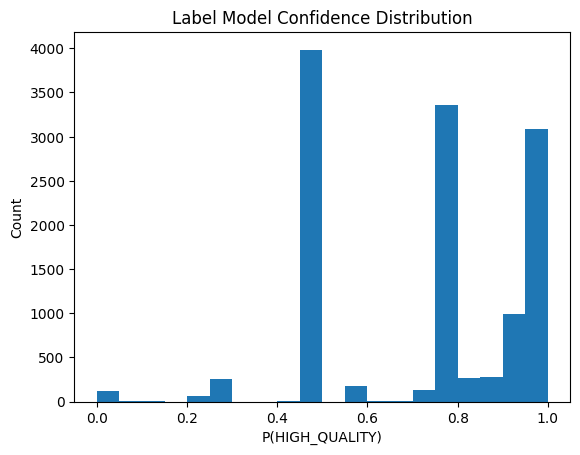

In [37]:
# Probabilistic labels
probs_train = label_model.predict_proba(L=L_train)

plt.hist(probs_train[:, HIGH_QUALITY], bins=20)
plt.xlabel("P(HIGH_QUALITY)")
plt.ylabel("Count")
plt.title("Label Model Confidence Distribution")
plt.show()

In [38]:
# Check label distribution
preds_train = label_model.predict(L=L_train)
unique, counts = np.unique(preds_train, return_counts=True)
for u, c in zip(unique, counts):
    name = {-1: "ABSTAIN", 0: "LOW_QUALITY", 1: "HIGH_QUALITY"}[u]
    print(f"  {name}: {c} ({c/len(preds_train)*100:.1f}%)")

  ABSTAIN: 3936 (30.9%)
  LOW_QUALITY: 497 (3.9%)
  HIGH_QUALITY: 8300 (65.2%)


### Filter unlabeled data points

In [39]:
from snorkel.labeling import filter_unlabeled_dataframe

df_train_filtered, probs_filtered = filter_unlabeled_dataframe(
    X=df_train, y=probs_train, L=L_train
)
print(f"Filtered: {len(df_train_filtered)} labeled out of {len(df_train)} total")

Filtered: 8797 labeled out of 12733 total


In [40]:
print("Coverage:", len(df_train_filtered) / len(df_train))

Coverage: 0.6908819602607398


## 5. Train a Classifier

In [41]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from snorkel.utils import probs_to_preds

In [42]:
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=50000)
X_train = vectorizer.fit_transform(df_train_filtered["review/text"].tolist())
X_test = vectorizer.transform(df_test["review/text"].tolist())

y_train = probs_to_preds(probs=probs_filtered)
print(f"Features: {X_train.shape}, Train labels: {y_train.shape}")

Features: (8797, 50000), Train labels: (8797,)


In [43]:
clf = LogisticRegression(C=0.143, solver="liblinear", max_iter=1000)
clf.fit(X=X_train, y=y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.143
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [44]:
test_preds = clf.predict(X_test)

unique, counts = np.unique(test_preds, return_counts=True)
print("Test set predictions:")
for u, c in zip(unique, counts):
    name = {0: "LOW_QUALITY", 1: "HIGH_QUALITY"}[u]
    print(f"  {name}: {c} ({c/len(test_preds)*100:.1f}%)")

Test set predictions:
  LOW_QUALITY: 249 (11.1%)
  HIGH_QUALITY: 1998 (88.9%)


In [45]:
# Considering the following Labels to be True Labels(or ground Truth) for the Learning Purpose only


# Proxy ground truth from test set signals we didn't use in training
# High helpfulness + decent length = likely HIGH_QUALITY
# Very short + no votes = likely LOW_QUALITY
def make_proxy_label(row):
    if row.total_votes >= 3 and row.help_ratio > 0.7 and row.word_count > 40:
        return HIGH_QUALITY
    if row.word_count < 15 and row.total_votes == 0:
        return LOW_QUALITY
    return ABSTAIN  # uncertain

proxy_labels = df_test.apply(make_proxy_label, axis=1).values
mask = proxy_labels != ABSTAIN
print(f"\nProxy ground truth available for {mask.sum()} / {len(df_test)} test points")


Proxy ground truth available for 532 / 2247 test points


In [46]:
from sklearn.metrics import accuracy_score, classification_report
if mask.sum() > 0:
    acc = accuracy_score(proxy_labels[mask], test_preds[mask])
    print(f"Accuracy on proxy-labeled subset: {acc * 100:.1f}%")
    print("\n")
    print(classification_report(
        proxy_labels[mask], test_preds[mask],
        target_names=['LOW_QUALITY', 'HIGH_QUALITY']
    ))

Accuracy on proxy-labeled subset: 99.6%


              precision    recall  f1-score   support

 LOW_QUALITY       0.60      1.00      0.75         3
HIGH_QUALITY       1.00      1.00      1.00       529

    accuracy                           1.00       532
   macro avg       0.80      1.00      0.87       532
weighted avg       1.00      1.00      1.00       532



## 6. Data Slicing — Monitor Critical Subsets

In [47]:
from snorkel.slicing import slicing_function, PandasSFApplier, SlicingFunction
from snorkel.analysis import Scorer

In [48]:
@slicing_function()
def sf_short(x):
    return x.word_count < 15

@slicing_function()
def sf_very_long(x):
    return x.word_count > 300

@slicing_function()
def sf_no_votes(x):
    return x.total_votes == 0

@slicing_function()
def sf_extreme_score(x):
    return x["review/score"] in (1, 5)

@slicing_function()
def sf_fiction(x):
    return "Fiction" in str(x.category)

sfs = [sf_short, sf_very_long, sf_no_votes, sf_extreme_score, sf_fiction]

In [49]:
sf_applier = PandasSFApplier(sfs)
S_test = sf_applier.apply(df_test)

# Show slice sizes
for sf in sfs:
    count = S_test[sf.name].sum()
    print(f"  {sf.name}: {count} ({count/len(df_test)*100:.1f}%)")

100%|████████████████████████████████████| 2247/2247 [00:00<00:00, 86509.47it/s]

  sf_short: 12 (0.5%)
  sf_very_long: 253 (11.3%)
  sf_no_votes: 651 (29.0%)
  sf_extreme_score: 1548 (68.9%)
  sf_fiction: 801 (35.6%)


## 7. End-to-End Results

In [50]:
# Apply the full pipeline on test set and show classified examples.
# Assuming test set is a different dataset that needs to be labeled by the Classifier trained using Weak Supervision

df_test["predicted_label"] = test_preds
df_test["label_name"] = df_test["predicted_label"].map({0: "LOW_QUALITY", 1: "HIGH_QUALITY"})
df_test["confidence"] = clf.predict_proba(X_test).max(axis=1)

In [51]:
print("="*80)
print("HIGH_QUALITY Examples (highest confidence)")
print("="*80)
hq = df_test[df_test.predicted_label == HIGH_QUALITY].nlargest(5, "confidence")
for _, r in hq.iterrows():
    print(f"\n[{r['review/score']}★ | {r['review/helpfulness']} helpful | conf={r.confidence:.3f}]")
    print(f"Title: {r.Title}")
    print(f"Summary: {r['review/summary']}")
    print(f"Text: {str(r['review/text'])[:250]}...")
    print("-"*40)

HIGH_QUALITY Examples (highest confidence)

[2★ | 3/3 helpful | conf=1.000]
Title: We Were the Mulvaneys (A William Abrahams Book)
Summary: Slow Motion Family Disintegration and Quick Reconnection
Text: The Mulvaneys were living the American dream . . . until their perfect daughter, Marianne, was brutally raped while drunk on Prom night. No one in the family is able to deal with the reality, and their inability to cope drives a splintering wedge int...
----------------------------------------

[4★ | 15/15 helpful | conf=1.000]
Title: Universal Artificial Intelligence: Sequential Decisions Based On Algorithmic Probability
Summary: Very ambitious project.
Text: This book differs from most books on the theoretical formulations of artificial intelligence in that it attempts to give a more rigorous accounting of machine learning and to rank machines according to their intelligence. To accomplish this ranking, ...
----------------------------------------

[4★ | 1/1 helpful | conf=1.000]
Titl

In [52]:
print("="*80)
print("LOW_QUALITY Examples (highest confidence)")
print("="*80)
lq = df_test[df_test.predicted_label == LOW_QUALITY].nlargest(5, "confidence")
for _, r in lq.iterrows():
    print(f"\n[{r['review/score']}★ | {r['review/helpfulness']} helpful | conf={r.confidence:.3f}]")
    print(f"Title: {r.Title}")
    print(f"Summary: {r['review/summary']}")
    print(f"Text: {str(r['review/text'])[:250]}...")
    print("-"*40)

LOW_QUALITY Examples (highest confidence)

[5★ | 0/0 helpful | conf=0.957]
Title: 204 Rosewood Lane (Cedar Cove, Book 2)
Summary: Happy
Text: Recieved the product in a very timely manner. I am pleased with the process. Thank you. It was shipped so fast and it was as described....
----------------------------------------

[5★ | 0/0 helpful | conf=0.937]
Title: The Covenant (Abram's Daughters)
Summary: The Covenant
Text: Book arrived on time in excellent condition. I would order again from this seller very happy with arrival and condition....
----------------------------------------

[5★ | 0/14 helpful | conf=0.919]
Title: Apostle of the Crucified Lord: A Theological Introduction to Paul and His Letters
Summary: apostle of the crucified lord
Text: Book arrived in immaculate condition much sooner than I anticipated. Would definitely buy again from this seller....
----------------------------------------

[5★ | 2/3 helpful | conf=0.906]
Title: The Little Teardrop
Summary: Excellent Book!
T

In [53]:
# The interesting cases: 5★ rated but classified as LOW_QUALITY
print("="*80)
print("5★ reviews classified as LOW_QUALITY (score ≠ quality)")
print("="*80)
mismatch = df_test[(df_test["review/score"] == 5) & (df_test.predicted_label == LOW_QUALITY)]
mismatch = mismatch.nlargest(5, "confidence")
for _, r in mismatch.iterrows():
    print(f"\n[{r['review/score']}★ but LOW_QUALITY | conf={r.confidence:.3f}]")
    print(f"Text: {str(r['review/text'])[:200]}")
    print("-"*40)

5★ reviews classified as LOW_QUALITY (score ≠ quality)

[5★ but LOW_QUALITY | conf=0.957]
Text: Recieved the product in a very timely manner. I am pleased with the process. Thank you. It was shipped so fast and it was as described.
----------------------------------------

[5★ but LOW_QUALITY | conf=0.937]
Text: Book arrived on time in excellent condition. I would order again from this seller very happy with arrival and condition.
----------------------------------------

[5★ but LOW_QUALITY | conf=0.919]
Text: Book arrived in immaculate condition much sooner than I anticipated. Would definitely buy again from this seller.
----------------------------------------

[5★ but LOW_QUALITY | conf=0.906]
Text: I read this because it was my aunt who wrote it!! Go PAM! It was incredibly cute, and the author/illustrater should be commended.
----------------------------------------

[5★ but LOW_QUALITY | conf=0.904]
Text: Had never read Jane Austin before. Read this for my book club, very enjoyab

In [54]:
# 1★ reviews classified as HIGH_QUALITY (negative but substantive)
print("="*80)
print("1★ reviews classified as HIGH_QUALITY (negative but substantive)")
print("="*80)
neg_hq = df_test[(df_test["review/score"] == 1) & (df_test.predicted_label == HIGH_QUALITY)]
neg_hq = neg_hq.nlargest(5, "confidence")
for _, r in neg_hq.iterrows():
    print(f"\n[{r['review/score']}★ but HIGH_QUALITY | conf={r.confidence:.3f}]")
    print(f"Text: {str(r['review/text'])[:250]}...")
    print("-"*40)

1★ reviews classified as HIGH_QUALITY (negative but substantive)

[1★ but HIGH_QUALITY | conf=1.000]
Text: At long last, I have completed this dreadful book. I started reading Oliver Twist ten months ago and swore it off a half-dozen times. I disliked right from the first chapter, but the deeper I got, the more I felt compelled to finish it so I could tru...
----------------------------------------

[1★ but HIGH_QUALITY | conf=1.000]
Text: "...it should be thrown with great force." That is, if it didn't weigh a 1100 pounds. Other reviewers have pointed out the terrible characterization, the rote repetition, the need for an editor, the condescending, arrogant, hateful sanctimony of the ...
----------------------------------------

[1★ but HIGH_QUALITY | conf=1.000]
Text: This is the first book of its kind I know of: nobody has ever dealt with this subject at such length before. But there are some good reasons for this:1. Did somebody say "royal family"? A discussion of the Saudi economy

### Final Summary

In [55]:
print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"Raw data:              {len(df_raw)} sampled reviews")
print(f"After cleaning:        {len(df)} reviews")
print(f"Train / Test:          {len(df_train)} / {len(df_test)}")
print(f"Labeling functions:    {len(lfs)}")
print(f"LF-labeled (filtered): {len(df_train_filtered)}")
print(f"Coverage:              {len(df_train_filtered)/len(df_train)*100:.1f}%")
print(f"")
print(f"Test predictions:")
print(f"  HIGH_QUALITY: {(test_preds == 1).sum()} ({(test_preds == 1).mean()*100:.1f}%)")
print(f"  LOW_QUALITY:  {(test_preds == 0).sum()} ({(test_preds == 0).mean()*100:.1f}%)")
print(f"")
print("Goal achieved: Reviews are labeled by QUALITY, not by star rating.")
print("A 5★ review saying 'shipped fast' → LOW_QUALITY")
print("A 1★ review with detailed criticism → HIGH_QUALITY")
print("="*60)


PIPELINE SUMMARY
Raw data:              15000 sampled reviews
After cleaning:        14980 reviews
Train / Test:          12733 / 2247
Labeling functions:    18
LF-labeled (filtered): 8797
Coverage:              69.1%

Test predictions:
  HIGH_QUALITY: 1998 (88.9%)
  LOW_QUALITY:  249 (11.1%)

Goal achieved: Reviews are labeled by QUALITY, not by star rating.
A 5★ review saying 'shipped fast' → LOW_QUALITY
A 1★ review with detailed criticism → HIGH_QUALITY
